# 1. Business Problem Statement

 Our company is entering the film production industry without prior experience.
 We aim to analyze existing movie data to discover which types of movies succeed at the box office.
 
## Objective: 
Make data-driven decisions to launch a profitable movie studio.

# 2. Business Solution
 Analyze multiple movie datasets to:
- Discover profitable genres.
- Determine ideal production budgets.
- Identify the best release dates.
- Analyze the relationship between budgets and profits.
- Generate actionable recommendations.

# 3. Business Objectives
- Which movie genres deliver the highest profitability when considering both revenue and production budgets?
- Which genres consistently receive the highest average ratings from audiences?
- What current and emerging trends are observable in movie genres, themes, and production techniques?
- Which writers, directors, and producers have demonstrated consistent success and would be strategic partners for future projects?



# 4. Data Overview
We will use the following datasets:
- bom.movie_gross.csv.gz
- rt.movie_info.tsv.gz
- rt.reviews.tsv.gz
- tmdb.movies.csv.gz
- tn.movie_budgets.csv.gz

# 5. Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy import stats
import statsmodels.api as sm

sns.set(style="whitegrid")

# 6. Load Datasets
We will load the first five datasets 

In [9]:
df = pd.read_csv('data/bom.movie_gross.csv/bom.movie_gross.csv')
df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [10]:
df.columns

Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year'], dtype='object')

In [11]:
df1 = pd.read_csv('data/rt.movie_info.tsv.gz', sep='\t')
df1

,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,currency,box_office,runtime,studio
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,"Oct 9, 1971","Sep 25, 2001",NaN,NaN,104 minutes,NaN
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,"Aug 17, 2012","Jan 1, 2013",$,"600,000",108 minutes,Entertainment One
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,"Sep 13, 1996","Apr 18, 2000",NaN,NaN,116 minutes,NaN
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,"Dec 9, 1994","Aug 27, 1997",NaN,NaN,128 minutes,NaN
4,7,NaN,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaN,NaN,NaN,NaN,200 minutes,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1555,1996,Forget terrorists or hijackers -- there's a ha...,R,Action and Adventure|Horror|Mystery and Suspense,NaN,NaN,"Aug 18, 2006","Jan 2, 2007",$,"33,886,034",106 minutes,New Line Cinema
1556,1997,The popular Saturday Night Live sketch was exp...,PG,Comedy|Science Fiction and Fantasy,Steve Barron,Terry Turner|Tom Davis|Dan Aykroyd|Bonnie Turner,"Jul 23, 1993","Apr 17, 2001",NaN,NaN,88 minutes,Paramount Vantage
1557,1998,"Based on a novel by Richard Powell, when the l...",G,Classics|Comedy|Drama|Musical and Performing Arts,Gordon Douglas,NaN,"Jan 1, 1962","May 11, 2004",NaN,NaN,111 minutes,NaN
1558,1999,The Sandlot is a coming-of-age story about a g...,PG,Comedy|Drama|Kids and Family|Sports and Fitness,David Mickey Evans,David Mickey Evans|Robert Gunter,"Apr 1, 1993","Jan 29, 2002",NaN,NaN,101 minutes,NaN


In [12]:
df1.columns

Index(['id', 'synopsis', 'rating', 'genre', 'director', 'writer',
       'theater_date', 'dvd_date', 'currency', 'box_office', 'runtime',
       'studio'],
      dtype='object')

In [13]:
df2 = pd.read_csv('data/rt.reviews.tsv.gz', sep='\t', encoding='latin_1')
df2

,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"
...,...,...,...,...,...,...,...,...
54427,2000,The real charm of this trifle is the deadpan c...,NaN,fresh,Laura Sinagra,1,Village Voice,"September 24, 2002"
54428,2000,NaN,1/5,rotten,Michael Szymanski,0,Zap2it.com,"September 21, 2005"
54429,2000,NaN,2/5,rotten,Emanuel Levy,0,EmanuelLevy.Com,"July 17, 2005"
54430,2000,NaN,2.5/5,rotten,Christopher Null,0,Filmcritic.com,"September 7, 2003"


In [14]:
df2.columns

Index(['id', 'review', 'rating', 'fresh', 'critic', 'top_critic', 'publisher',
       'date'],
      dtype='object')

In [15]:
df3 = pd.read_csv('data/tmdb.movies.csv.gz')
df3.head()

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


In [16]:
df3.columns

Index(['Unnamed: 0', 'genre_ids', 'id', 'original_language', 'original_title',
       'popularity', 'release_date', 'title', 'vote_average', 'vote_count'],
      dtype='object')

In [17]:
df4 = pd.read_csv('data/tn.movie_budgets.csv.gz')
df4

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


In [18]:
df4.columns

Index(['id', 'release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross'],
      dtype='object')

# 7. Data Cleaning

In [19]:
print("Before cleaning:")
print(df.shape, df1.shape, df2.shape, df3.shape, df4.shape)

Before cleaning:
(3387, 5) (1560, 12) (54432, 8) (26517, 10) (5782, 6)


### Removing duplicates
Lets remove all duplicate rows in the dataframes

In [20]:
df.drop_duplicates(inplace=True)
df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)
df3.drop_duplicates(inplace=True)
df4.drop_duplicates(inplace=True)

### Fix money columns
Lets remove all duplicate rows in the dataframes


In [21]:
df['domestic_gross'] = pd.to_numeric(df['domestic_gross'], errors='coerce')
df['foreign_gross'] = pd.to_numeric(df['foreign_gross'], errors='coerce')
df4['production_budget'] = df4['production_budget'].replace('[\\$,]', '', regex=True).astype(float)
df4['domestic_gross'] = df4['domestic_gross'].replace('[\\$,]', '', regex=True).astype(float)
df4['worldwide_gross'] = df4['worldwide_gross'].replace('[\\$,]', '', regex=True).astype(float)

### Fix Date Columns

In [22]:
df1['theater_date'] = pd.to_datetime(df1['theater_date'], errors='coerce')
df1['dvd_date'] = pd.to_datetime(df1['dvd_date'], errors='coerce')
df4['release_date'] = pd.to_datetime(df4['release_date'], errors='coerce')

In [23]:
print("After cleaning:")
print(df.shape, df1.shape, df2.shape, df3.shape, df4.shape)

After cleaning:
(3387, 5) (1560, 12) (54423, 8) (26517, 10) (5782, 6)


### fix title columns 

In [24]:
import pandas as pd
import re

def clean_title(title):
    if pd.isnull(title):
        return ""
    title = title.lower()  # lowercase
    title = title.strip()  # remove leading/trailing spaces
    title = re.sub(r'\s+', ' ', title)  # normalize multiple spaces
    title = re.sub(r'[^a-z0-9 ]', '', title)  # remove punctuation and special chars
    return title


In [25]:
df['clean_title'] = df['title'].apply(clean_title)
df4['clean_title'] = df4['movie'].apply(clean_title)
df3['clean_title'] = df3['title'].apply(clean_title)

# 8. Merge Datasets

In [26]:
df_merged = df.merge(df3, on='clean_title', how="inner")
df_merged

,title_x,studio,domestic_gross,foreign_gross,year,clean_title,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title_y,vote_average,vote_count
0,Toy Story 3,BV,415000000.0,652000000.0,2010,toy story 3,7,"[16, 10751, 35]",10193,en,Toy Story 3,24.445,2010-06-17,Toy Story 3,7.7,8340
1,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010,harry potter and the deathly hallows part 1,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
2,Inception,WB,292600000.0,535700000.0,2010,inception,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186
3,Shrek Forever After,P/DW,238700000.0,513900000.0,2010,shrek forever after,38,"[35, 12, 14, 16, 10751]",10192,en,Shrek Forever After,15.041,2010-05-16,Shrek Forever After,6.1,3843
4,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000.0,2010,the twilight saga eclipse,15,"[12, 14, 18, 10749]",24021,en,The Twilight Saga: Eclipse,20.340,2010-06-23,The Twilight Saga: Eclipse,6.0,4909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2842,The Escape,IFC,14000.0,NaN,2018,the escape,16803,"[53, 28]",459814,en,The Escape,0.600,2015-08-14,The Escape,7.0,1
2843,The Escape,IFC,14000.0,NaN,2018,the escape,19053,"[53, 28]",417004,en,The Escape,1.176,2016-10-23,The Escape,6.6,10
2844,Souvenir,Strand,11400.0,NaN,2018,souvenir,18483,"[35, 18]",408258,fr,Souvenir,2.130,2016-09-08,Souvenir,5.8,14
2845,The Quake,Magn.,6200.0,NaN,2018,the quake,24107,[12],416194,no,Skjelvet,11.051,2018-12-14,The Quake,6.7,81


In [27]:
df_merged.columns

Index(['title_x', 'studio', 'domestic_gross', 'foreign_gross', 'year',
       'clean_title', 'Unnamed: 0', 'genre_ids', 'id', 'original_language',
       'original_title', 'popularity', 'release_date', 'title_y',
       'vote_average', 'vote_count'],
      dtype='object')

In [28]:
#lets drop unnecessary columns
df_merged = df_merged.drop(columns=['Unnamed: 0', 'title_y', 'original_title', 'id', 'genre_ids'])
df_merged.head()

,title_x,studio,domestic_gross,foreign_gross,year,clean_title,original_language,popularity,release_date,vote_average,vote_count
0,Toy Story 3,BV,415000000.0,652000000.0,2010,toy story 3,en,24.445,2010-06-17,7.7,8340
1,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010,harry potter and the deathly hallows part 1,en,33.533,2010-11-19,7.7,10788
2,Inception,WB,292600000.0,535700000.0,2010,inception,en,27.920,2010-07-16,8.3,22186
3,Shrek Forever After,P/DW,238700000.0,513900000.0,2010,shrek forever after,en,15.041,2010-05-16,6.1,3843
4,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000.0,2010,the twilight saga eclipse,en,20.340,2010-06-23,6.0,4909


In [29]:
#Drop null values
dfw = df_merged.dropna()
dfw

,title_x,studio,domestic_gross,foreign_gross,year,clean_title,original_language,popularity,release_date,vote_average,vote_count
0,Toy Story 3,BV,415000000.0,652000000.0,2010,toy story 3,en,24.445,2010-06-17,7.7,8340
1,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010,harry potter and the deathly hallows part 1,en,33.533,2010-11-19,7.7,10788
2,Inception,WB,292600000.0,535700000.0,2010,inception,en,27.920,2010-07-16,8.3,22186
3,Shrek Forever After,P/DW,238700000.0,513900000.0,2010,shrek forever after,en,15.041,2010-05-16,6.1,3843
4,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000.0,2010,the twilight saga eclipse,en,20.340,2010-06-23,6.0,4909
...,...,...,...,...,...,...,...,...,...,...,...
2784,Bilal: A New Breed of Hero,VE,491000.0,1700000.0,2018,bilal a new breed of hero,en,2.707,2018-02-02,6.8,54
2787,I Still See You,LGF,1400.0,1500000.0,2018,i still see you,en,12.867,2018-10-12,6.8,196
2797,The Catcher Was a Spy,IFC,725000.0,229000.0,2018,the catcher was a spy,en,9.727,2018-06-22,6.2,67
2809,Time Freak,Grindstone,10000.0,256000.0,2018,time freak,en,1.604,2011-02-10,6.9,9


In [30]:
dfw1 = dfw.merge(df4, on='clean_title', how="left")
dfw1

,title_x,studio,domestic_gross_x,foreign_gross,year,clean_title,original_language,popularity,release_date_x,vote_average,vote_count,id,release_date_y,movie,production_budget,domestic_gross_y,worldwide_gross
0,Toy Story 3,BV,415000000.0,652000000.0,2010,toy story 3,en,24.445,2010-06-17,7.7,8340,47.0,2010-06-18,Toy Story 3,200000000.0,415004880.0,1.068880e+09
1,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010,harry potter and the deathly hallows part 1,en,33.533,2010-11-19,7.7,10788,NaN,NaT,NaN,NaN,NaN,NaN
2,Inception,WB,292600000.0,535700000.0,2010,inception,en,27.920,2010-07-16,8.3,22186,38.0,2010-07-16,Inception,160000000.0,292576195.0,8.355246e+08
3,Shrek Forever After,P/DW,238700000.0,513900000.0,2010,shrek forever after,en,15.041,2010-05-16,6.1,3843,27.0,2010-05-21,Shrek Forever After,165000000.0,238736787.0,7.562447e+08
4,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000.0,2010,the twilight saga eclipse,en,20.340,2010-06-23,6.0,4909,53.0,2010-06-30,The Twilight Saga: Eclipse,68000000.0,300531751.0,7.061028e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1797,Bilal: A New Breed of Hero,VE,491000.0,1700000.0,2018,bilal a new breed of hero,en,2.707,2018-02-02,6.8,54,100.0,2018-02-02,Bilal: A New Breed of Hero,30000000.0,490973.0,6.485990e+05
1798,I Still See You,LGF,1400.0,1500000.0,2018,i still see you,en,12.867,2018-10-12,6.8,196,NaN,NaT,NaN,NaN,NaN,NaN
1799,The Catcher Was a Spy,IFC,725000.0,229000.0,2018,the catcher was a spy,en,9.727,2018-06-22,6.2,67,NaN,NaT,NaN,NaN,NaN,NaN
1800,Time Freak,Grindstone,10000.0,256000.0,2018,time freak,en,1.604,2011-02-10,6.9,9,NaN,NaT,NaN,NaN,NaN,NaN


In [31]:
# Drop unnecessary columns
dfw1 = dfw1.drop(columns=[
    'clean_title', 'id', 'release_date_y', 'movie', 'domestic_gross_x'
])

# Rename columns for clarity
dfw1 = dfw1.rename(columns={'title_x': 'title', 'release_date_x': 'release_date', 'domestic_gross_y':'domestic_gross'})


In [32]:
dfw1

,title,studio,foreign_gross,year,original_language,popularity,release_date,vote_average,vote_count,production_budget,domestic_gross,worldwide_gross
0,Toy Story 3,BV,652000000.0,2010,en,24.445,2010-06-17,7.7,8340,200000000.0,415004880.0,1.068880e+09
1,Harry Potter and the Deathly Hallows Part 1,WB,664300000.0,2010,en,33.533,2010-11-19,7.7,10788,NaN,NaN,NaN
2,Inception,WB,535700000.0,2010,en,27.920,2010-07-16,8.3,22186,160000000.0,292576195.0,8.355246e+08
3,Shrek Forever After,P/DW,513900000.0,2010,en,15.041,2010-05-16,6.1,3843,165000000.0,238736787.0,7.562447e+08
4,The Twilight Saga: Eclipse,Sum.,398000000.0,2010,en,20.340,2010-06-23,6.0,4909,68000000.0,300531751.0,7.061028e+08
...,...,...,...,...,...,...,...,...,...,...,...,...
1797,Bilal: A New Breed of Hero,VE,1700000.0,2018,en,2.707,2018-02-02,6.8,54,30000000.0,490973.0,6.485990e+05
1798,I Still See You,LGF,1500000.0,2018,en,12.867,2018-10-12,6.8,196,NaN,NaN,NaN
1799,The Catcher Was a Spy,IFC,229000.0,2018,en,9.727,2018-06-22,6.2,67,NaN,NaN,NaN
1800,Time Freak,Grindstone,256000.0,2018,en,1.604,2011-02-10,6.9,9,NaN,NaN,NaN


In [33]:
dfg = dfw1.dropna()
dfg

,title,studio,foreign_gross,year,original_language,popularity,release_date,vote_average,vote_count,production_budget,domestic_gross,worldwide_gross
0,Toy Story 3,BV,652000000.0,2010,en,24.445,2010-06-17,7.7,8340,200000000.0,415004880.0,1.068880e+09
2,Inception,WB,535700000.0,2010,en,27.920,2010-07-16,8.3,22186,160000000.0,292576195.0,8.355246e+08
3,Shrek Forever After,P/DW,513900000.0,2010,en,15.041,2010-05-16,6.1,3843,165000000.0,238736787.0,7.562447e+08
4,The Twilight Saga: Eclipse,Sum.,398000000.0,2010,en,20.340,2010-06-23,6.0,4909,68000000.0,300531751.0,7.061028e+08
5,Iron Man 2,Par.,311500000.0,2010,en,28.515,2010-05-07,6.8,12368,170000000.0,312433331.0,6.211564e+08
...,...,...,...,...,...,...,...,...,...,...,...,...
1774,Hotel Artemis,Global Road,6000000.0,2018,en,14.585,2018-06-08,5.9,471,15000000.0,6708137.0,1.275880e+07
1779,Kin,LGF,4300000.0,2018,en,23.805,2018-08-31,6.2,289,30000000.0,5718096.0,1.009682e+07
1783,Suspiria,Amazon,5400000.0,2018,en,16.925,2018-10-26,7.0,752,20000000.0,2483472.0,7.034615e+06
1787,Destroyer,Annapurna,4000000.0,2018,en,17.815,2018-12-25,5.9,176,9000000.0,1533324.0,3.681096e+06


In [34]:
def clean_studio(name):
    if pd.isnull(name):
        return ""
    name = name.lower().strip()
    name = re.sub(r'\s+', ' ', name)          # Normalize multiple spaces
    name = re.sub(r'[^a-z0-9& ]', '', name)   # Remove punctuation except "&"
    return name

In [35]:
dfg.loc[:, 'clean_studio'] = dfg['studio'].apply(clean_studio)
df1.loc[:, 'clean_studio'] = df1['studio'].apply(clean_studio)

C:\Users\002401\AppData\Local\Temp\ipykernel_26876\1243945274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfg.loc[:, 'clean_studio'] = dfg['studio'].apply(clean_studio)


In [36]:
df1 = df1.dropna()

In [37]:
merged_df = dfg.merge(df1, on='clean_studio', how='inner')
merged_df['genre'].unique()

array(['Drama|Mystery and Suspense',
       'Art House and International|Comedy|Drama|Musical and Performing Arts',
       'Drama|Horror|Mystery and Suspense', 'Drama',
       'Action and Adventure|Mystery and Suspense', 'Drama|Horror'],
      dtype=object)

In [38]:
merged_df.columns

Index(['title', 'studio_x', 'foreign_gross', 'year', 'original_language',
       'popularity', 'release_date', 'vote_average', 'vote_count',
       'production_budget', 'domestic_gross', 'worldwide_gross',
       'clean_studio', 'id', 'synopsis', 'rating', 'genre', 'director',
       'writer', 'theater_date', 'dvd_date', 'currency', 'box_office',
       'runtime', 'studio_y'],
      dtype='object')

In [39]:
# Drop unnecessary columns
merged_df = merged_df.drop(columns=[
    'studio_y', 'clean_studio', 'id', 'synopsis', 'dvd_date', 'theater_date', 'currency', 'box_office'
])

# Optionally rename studio_x to just 'studio'
merged_df = merged_df.rename(columns={'studio_x': 'studio'})
merged_df

,title,studio,foreign_gross,year,original_language,popularity,release_date,vote_average,vote_count,production_budget,domestic_gross,worldwide_gross,rating,genre,director,writer,runtime
0,Inception,WB,535700000.0,2010,en,27.920,2010-07-16,8.3,22186,160000000.0,292576195.0,835524642.0,R,Drama|Mystery and Suspense,Clint Eastwood,Brian Helgeland,137 minutes
1,Due Date,WB,111200000.0,2010,en,12.445,2010-11-04,6.3,2973,65000000.0,100539043.0,211739043.0,R,Drama|Mystery and Suspense,Clint Eastwood,Brian Helgeland,137 minutes
2,Yogi Bear,WB,101300000.0,2010,en,9.096,2010-12-17,5.3,387,80000000.0,100246011.0,204774690.0,R,Drama|Mystery and Suspense,Clint Eastwood,Brian Helgeland,137 minutes
3,The Book of Eli,WB,62300000.0,2010,en,18.985,2010-01-11,6.7,3495,80000000.0,94835059.0,158750817.0,R,Drama|Mystery and Suspense,Clint Eastwood,Brian Helgeland,137 minutes
4,The Town,WB,61800000.0,2010,en,13.476,2010-09-17,7.1,2386,37000000.0,92186262.0,152566881.0,R,Drama|Mystery and Suspense,Clint Eastwood,Brian Helgeland,137 minutes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,Lady Bird,A24,30000000.0,2017,en,15.974,2017-11-03,7.3,3866,10000000.0,48958273.0,78610769.0,R,Drama|Horror,Trey Edward Shults,Trey Edward Shults,91 minutes
149,The Disaster Artist,A24,8700000.0,2017,en,13.270,2017-12-01,7.2,1895,10000000.0,21120616.0,28717667.0,R,Drama|Horror,Trey Edward Shults,Trey Edward Shults,91 minutes
150,The Disaster Artist,A24,8700000.0,2017,en,13.270,2017-12-01,7.2,1895,10000000.0,21120616.0,28717667.0,R,Drama|Horror,Trey Edward Shults,Trey Edward Shults,91 minutes
151,It Comes At Night,A24,5300000.0,2017,en,12.337,2017-06-09,5.8,1141,5000000.0,13985117.0,19720203.0,R,Drama|Horror,Trey Edward Shults,Trey Edward Shults,91 minutes


In [40]:
merged_df['genre'].info()


<class 'pandas.core.series.Series'>
RangeIndex: 153 entries, 0 to 152
Series name: genre
Non-Null Count  Dtype 
--------------  ----- 
153 non-null    object
dtypes: object(1)
memory usage: 1.3+ KB


# Hypothesis Testing 
## Hypothesis 
For Hypothesis testing we will use the objective 1 and 2:

1. Identify the movie genres that generate the highest profitability relative to production budgets.

2. Determine which genres achieve the highest average audience ratings.

### Profitability vs Production budget 
**Null** - There is NO significant difference in profitability relative to production budget across movie genres.

**ALT** - There is a significant difference in profitability relative to production budget across movie genre. 

### Average audience rating 
**Null** - Average audience rating does not differ by genre.

**Alt** - Average audience rating differs by genre.

### Profitability vs Production budget 

**Null** - There is NO significant difference in profitability relative to production budget across movie genres

**ALT** - There is a significant difference in profitability relative to production budget across movie genre 

In [41]:
#calculating profitability
merged_df['Profitability'] = merged_df['worldwide_gross']/ merged_df['production_budget'] -1
merged_df['Profitability']

0      4.222029
1      2.257524
2      1.559684
3      0.984385
4      3.123429
         ...   
148    6.861077
149    1.871767
150    1.871767
151    2.944041
152    6.013390
Name: Profitability, Length: 153, dtype: float64

In [42]:
#Calculate t statistics for profitability by genre
t_stats = merged_df.groupby('genre')['Profitability'].agg(['mean', 'std', 'count']).reset_index()
t_stats

,genre,mean,std,count
0,Action and Adventure|Mystery and Suspense,2.052134,1.724911,2
1,Art House and International|Comedy|Drama|Music...,2.052134,1.724911,2
2,Drama,2.052134,1.724911,2
3,Drama|Horror,3.211399,3.622433,18
4,Drama|Horror|Mystery and Suspense,2.052134,1.724911,2
5,Drama|Mystery and Suspense,2.225041,4.491079,127


In [43]:
#ANOVA test for profitability by genre
#Grouping by genre
genre_groups = merged_df.groupby('genre')['Profitability'].apply(list)
genre_groups

genre
Action and Adventure|Mystery and Suspense                                        [0.8324374999999999, 3.2718304399999996]
Art House and International|Comedy|Drama|Musical and Performing Arts             [0.8324374999999999, 3.2718304399999996]
Drama                                                                            [0.8324374999999999, 3.2718304399999996]
Drama|Horror                                                            [5.2298502, -0.55765625, -0.55765625, -0.62585...
Drama|Horror|Mystery and Suspense                                                [0.8324374999999999, 3.2718304399999996]
Drama|Mystery and Suspense                                              [4.2220290125, 2.2575237384615385, 1.559683625...
Name: Profitability, dtype: object

In [44]:
#Performing ANOVA test
f_statistic, p_value = stats.f_oneway(*genre_groups)
print(f'fstatistic: {f_statistic}, p_value:{p_value}')

fstatistic: 0.1694266000742014, p_value:0.9735110557972944


## Plotting Results

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Drama|Mystery and Suspense'),
  Text(1, 0, 'Art House and International|Comedy|Drama|Musical and Performing Arts'),
  Text(2, 0, 'Drama|Horror|Mystery and Suspense'),
  Text(3, 0, 'Drama'),
  Text(4, 0, 'Action and Adventure|Mystery and Suspense'),
  Text(5, 0, 'Drama|Horror')])

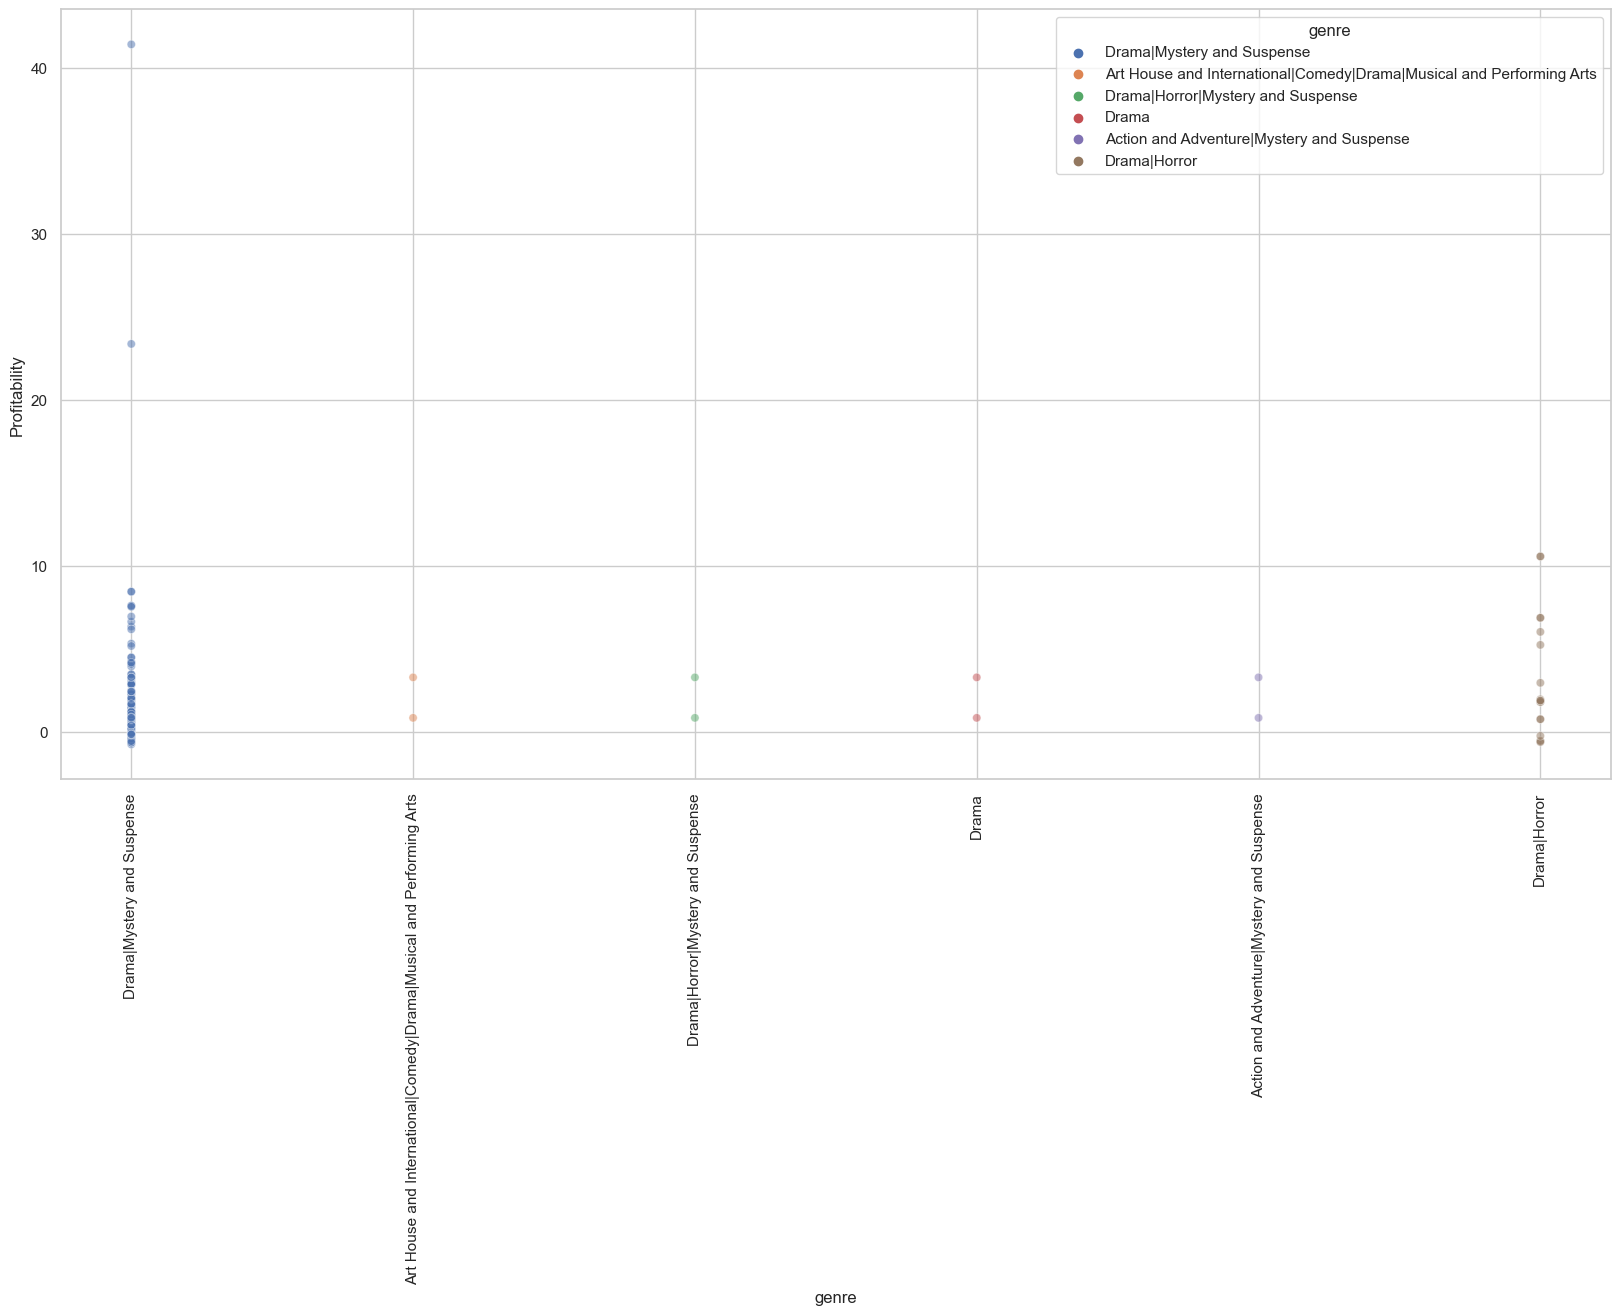

In [45]:
#Plotting the results
plt.figure(figsize=(20,10))
sns.scatterplot(data= merged_df, x = 'genre', y = 'Profitability', hue = 'genre', alpha = 0.5)
plt.xticks(rotation=90)


Based on our results our p value is greater than 0.05, there for we have failed to reject our null hypothesis meaning that there is no significant difference in profitability across the movie genres.


### Average audience rating 
**Null** - Average audience rating does not differ by genre

**Alt** - Average audience rating differs by genre



In [46]:
#Calculating average audience rating by genre
avg_audience_rating = merged_df.groupby('genre')['vote_count'].mean().reset_index()
avg_audience_rating

,genre,vote_count
0,Action and Adventure|Mystery and Suspense,1809.500000
1,Art House and International|Comedy|Drama|Music...,1809.500000
2,Drama,1809.500000
3,Drama|Horror,2565.500000
4,Drama|Horror|Mystery and Suspense,1809.500000
5,Drama|Mystery and Suspense,3305.818898


In [47]:
#grouping by genre and calculating ANOVA test for audience rating 
genre_groups_audience = merged_df.groupby('genre')['vote_count'].apply(list)
genre_groups_audience


genre
Action and Adventure|Mystery and Suspense                                                                    [1383, 2236]
Art House and International|Comedy|Drama|Musical and Performing Arts                                         [1383, 2236]
Drama                                                                                                        [1383, 2236]
Drama|Horror                                                            [2495, 792, 792, 435, 8026, 5494, 5494, 609, 6...
Drama|Horror|Mystery and Suspense                                                                            [1383, 2236]
Drama|Mystery and Suspense                                              [22186, 2973, 387, 3495, 2386, 1223, 273, 1748...
Name: vote_count, dtype: object

In [48]:
#Performing ANOVA test
f_statistic_audience, p_value_audience = stats.f_oneway(*genre_groups_audience)
print(f'fstatistic: {f_statistic_audience}, p_value:{p_value_audience}')

fstatistic: 0.37783170115230763, p_value:0.8633158214856644


Our results show that we have failed to reject the null hypothesis meaning audience rating does not differ by genre.


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Drama|Mystery and Suspense'),
  Text(1, 0, 'Art House and International|Comedy|Drama|Musical and Performing Arts'),
  Text(2, 0, 'Drama|Horror|Mystery and Suspense'),
  Text(3, 0, 'Drama'),
  Text(4, 0, 'Action and Adventure|Mystery and Suspense'),
  Text(5, 0, 'Drama|Horror')])

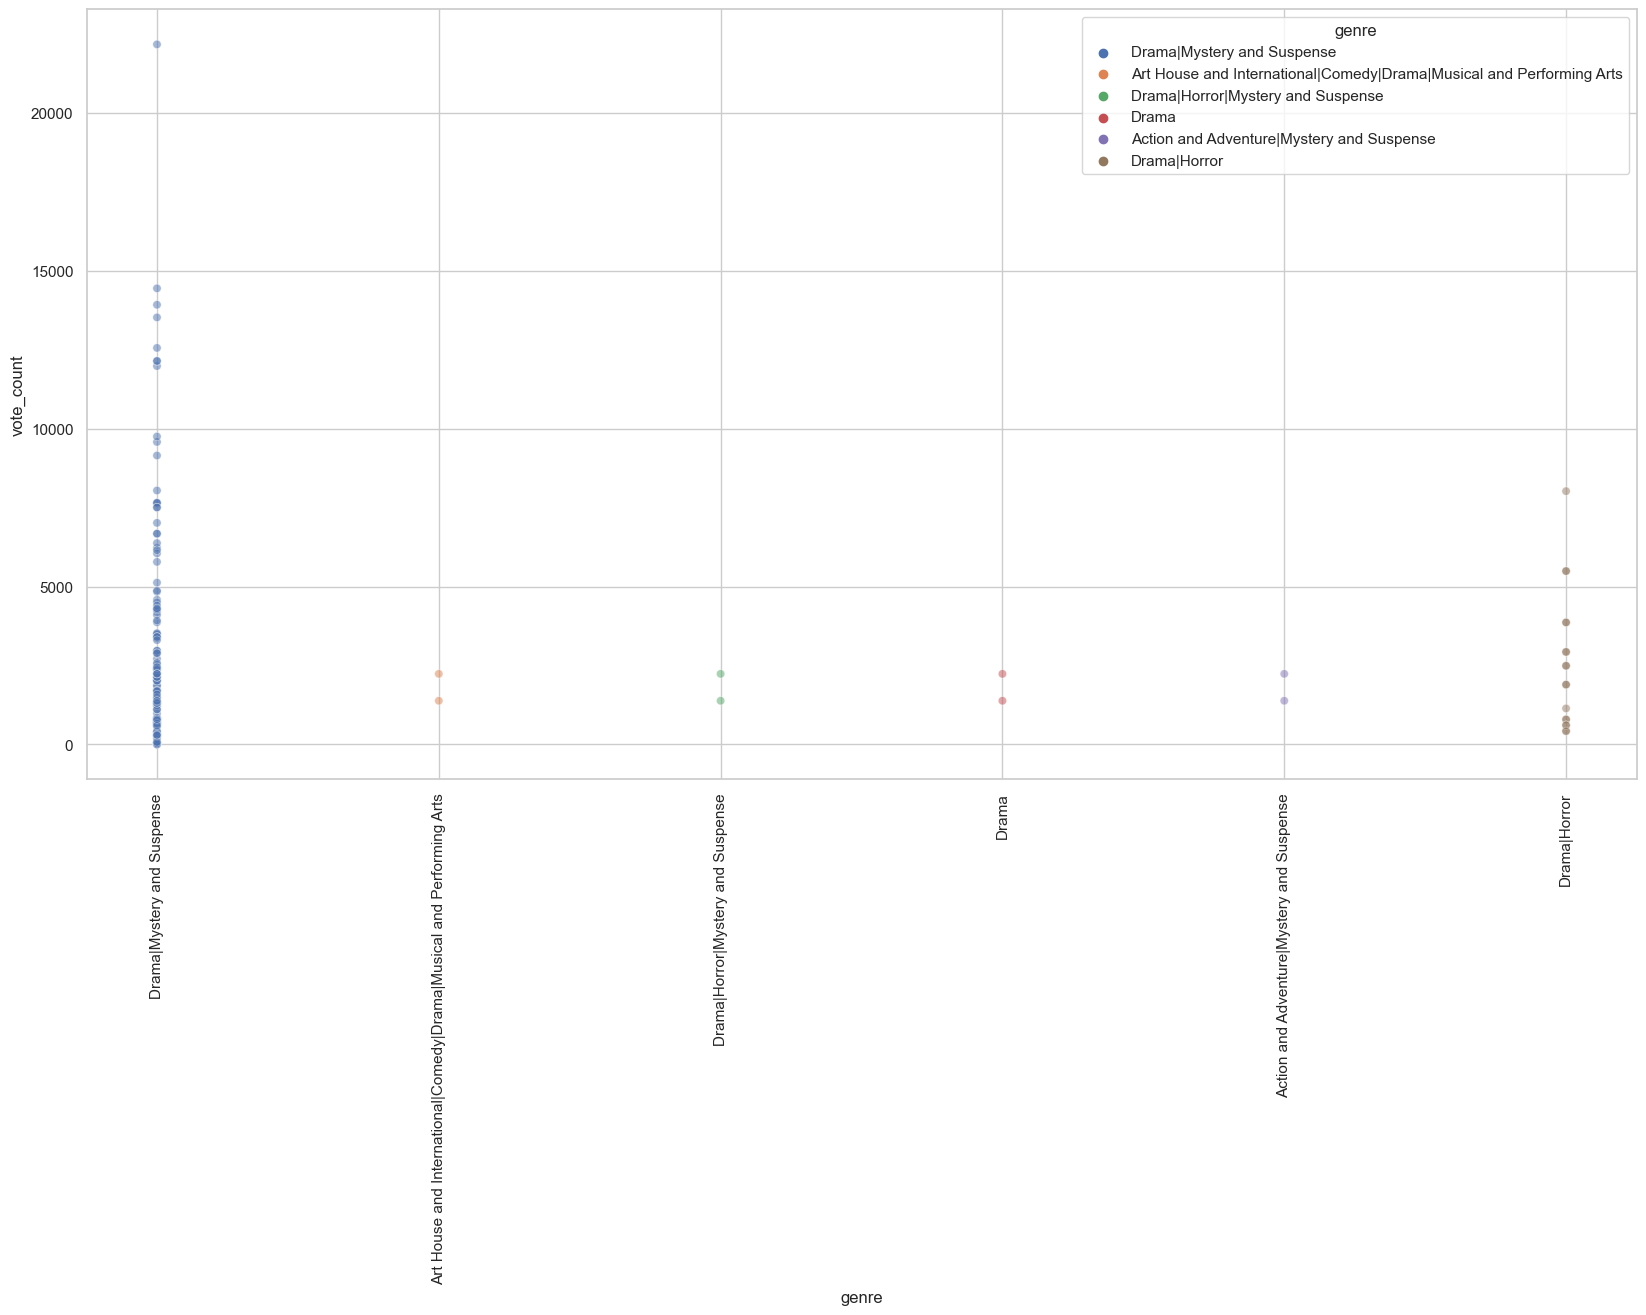

In [49]:
#Plotting the results
plt.figure(figsize=(20,10))
sns.scatterplot(data= merged_df, x = 'genre', y = 'vote_count', hue = 'genre', alpha = 0.5)
plt.xticks(rotation=90)

### LEARNINGS AND TAKEAWAYS
Our hypotheses questions both failed to reject the null hypothesis.


- We learn that genre doesn't really have an effect on audience rating nor does it have an effect on profit.

- Despite this there are several movies that fall in the Drama, Mystery and Suspense Genre. This tells us that we can create movies that fall in any of these genres. 

- From this we learned that we might have to do some deeper data cleaning so as to get better results e.g splitting up the genres based on primary genre. 



